# 🚗 BNU Vehicle Monitoring System
### AI-Powered Car Sticker & Number Plate Detection
**Model:** YOLOv8 | **Database:** SQLite | **OCR:** EasyOCR

---
### 📋 Steps:
1. Setup Environment
2. Download Dataset from Roboflow
3. Train YOLOv8 Model
4. Validate & Test
5. Save Weights
6. Real-time Detection App

## ✅ Step 1 — Check GPU & Setup Environment

In [1]:
# Check GPU
!nvidia-smi
import torch
print('\n✅ CUDA Available:', torch.cuda.is_available())
print('🖥️ GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')

Mon May 25 15:58:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install required libraries
!pip install ultralytics roboflow easyocr -q
print('✅ All libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 20.8 MB/s eta 0:00:00
✅ All libraries installed!


## ✅ Step 2 — Mount Google Drive (to save model weights)

In [4]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')

Mounted at /content/drive
✅ Google Drive mounted!


In [5]:
import zipfile
import os

# Extract dataset
zip_path = '/content/bnu-vehicle-detector.v1i.yolov8.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print('✅ Dataset extracted!')
print('📂 Structure:')
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')

✅ Dataset extracted!
📂 Structure:
dataset/
  train/
    labels/
    images/


## ✅ Step 4 — Train YOLOv8 Model

In [10]:
from ultralytics import YOLO

# Load YOLOv8 nano model (fastest, good for small datasets)
model = YOLO('yolov8n.pt')

# Train the model
results = model.train(
    data='/content/dataset/data.yaml',  # dataset config
    epochs=50,           # number of training epochs
    imgsz=640,           # image size
    batch=16,            # batch size
    name='bnu_detector', # experiment name
    patience=10,         # early stopping
    save=True,           # save weights
    device=0,            # GPU
    plots=True           # save training plots
)

print('✅ Training Complete!')

Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bnu_detector-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

In [8]:
import os
for root, dirs, files in os.walk('/content/dataset'):
    level = root.replace('/content/dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')

dataset/
  train/
    labels/
    images/


In [9]:
import os
import shutil
import random

# Paths
train_images = '/content/dataset/train/images'
train_labels = '/content/dataset/train/labels'

valid_images = '/content/dataset/valid/images'
valid_labels = '/content/dataset/valid/labels'
test_images = '/content/dataset/test/images'
test_labels = '/content/dataset/test/labels'

# Create folders
os.makedirs(valid_images, exist_ok=True)
os.makedirs(valid_labels, exist_ok=True)
os.makedirs(test_images, exist_ok=True)
os.makedirs(test_labels, exist_ok=True)

# Get all images
images = os.listdir(train_images)
random.shuffle(images)

# Split: 70% train, 20% valid, 10% test
total = len(images)
valid_count = int(total * 0.2)
test_count = int(total * 0.1)

valid_imgs = images[:valid_count]
test_imgs = images[valid_count:valid_count+test_count]

# Move to valid
for img in valid_imgs:
    shutil.move(f'{train_images}/{img}', f'{valid_images}/{img}')
    label = img.replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt')
    if os.path.exists(f'{train_labels}/{label}'):
        shutil.move(f'{train_labels}/{label}', f'{valid_labels}/{label}')

# Move to test
for img in test_imgs:
    shutil.move(f'{train_images}/{img}', f'{test_images}/{img}')
    label = img.replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt')
    if os.path.exists(f'{train_labels}/{label}'):
        shutil.move(f'{train_labels}/{label}', f'{test_labels}/{label}')

print(f'✅ Split complete!')
print(f'Train: {len(os.listdir(train_images))} images')
print(f'Valid: {len(os.listdir(valid_images))} images')
print(f'Test:  {len(os.listdir(test_images))} images')

✅ Split complete!
Train: 62 images
Valid: 17 images
Test:  8 images


In [11]:
# Save best weights
import shutil
shutil.copy(
    '/content/runs/detect/bnu_detector-2/weights/best.pt',
    '/content/best.pt'
)
print('✅ Weights saved!')
print('📁 Location: /content/best.pt')

✅ Weights saved!
📁 Location: /content/best.pt



image 1/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-47-36-PM_jpeg.rf.5366c0db82f3d85c1926c4c757f66b1f.jpg: 640x640 (no detections), 7.8ms
image 2/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-47-39-PM_jpeg.rf.18167b2388833a3607da58efb954fcad.jpg: 640x640 (no detections), 7.2ms
image 3/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-47-59-PM-1-_jpeg.rf.72b3d7823c4e8d2e5d18a702b27c62dd.jpg: 640x640 (no detections), 7.2ms
image 4/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-48-03-PM_jpeg.rf.2f9a212f75140e0cee6a20caec1d860c.jpg: 640x640 (no detections), 7.2ms
image 5/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-48-04-PM_jpeg.rf.842475ed55ca5204353369001d660dab.jpg: 640x640 (no detections), 7.2ms
image 6/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-6-18-29-PM-2-_jpeg.rf.b5d992d34a4ba4ef8d867f8e5a50587f.jpg: 640x640 (no detections), 8.6ms
image 7/8 /content/dataset/test/images/WhatsApp-Image-202

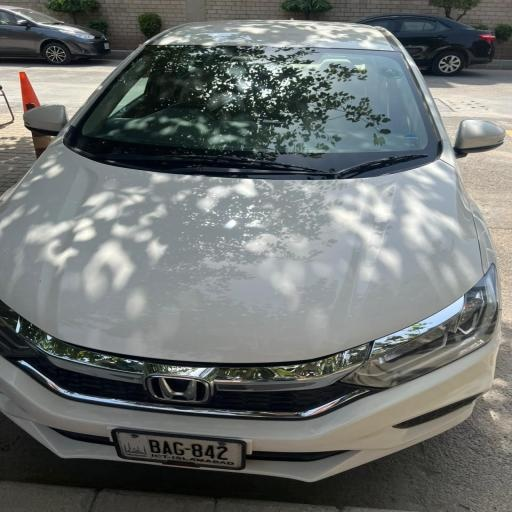

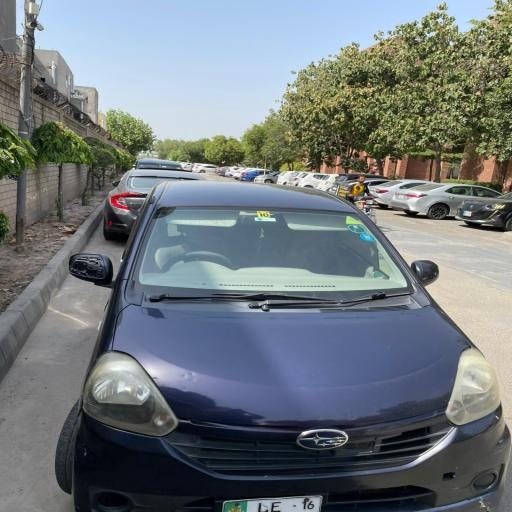

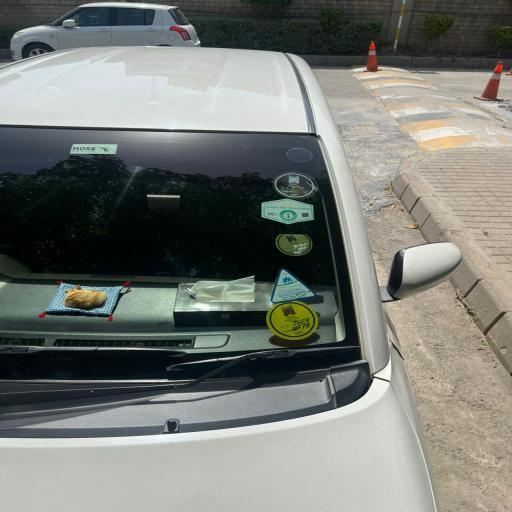

In [12]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob

# Load best model
model = YOLO('/content/best.pt')

# Test on test images
model.predict(
    source='/content/dataset/test/images',
    conf=0.25,
    save=True,
    name='bnu_test'
)

# Show results
pred_images = glob.glob('runs/detect/bnu_test/*.jpg')[:3]
for img in pred_images:
    display(Image(filename=img, width=600))


image 1/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-47-36-PM_jpeg.rf.5366c0db82f3d85c1926c4c757f66b1f.jpg: 640x640 1 number_plate, 29.0ms
image 2/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-47-39-PM_jpeg.rf.18167b2388833a3607da58efb954fcad.jpg: 640x640 (no detections), 22.3ms
image 3/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-47-59-PM-1-_jpeg.rf.72b3d7823c4e8d2e5d18a702b27c62dd.jpg: 640x640 (no detections), 30.4ms
image 4/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-48-03-PM_jpeg.rf.2f9a212f75140e0cee6a20caec1d860c.jpg: 640x640 1 number_plate, 20.3ms
image 5/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-48-04-PM_jpeg.rf.842475ed55ca5204353369001d660dab.jpg: 640x640 1 number_plate, 13.2ms
image 6/8 /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-6-18-29-PM-2-_jpeg.rf.b5d992d34a4ba4ef8d867f8e5a50587f.jpg: 640x640 1 number_plate, 11.5ms
image 7/8 /content/dataset/test/images/WhatsApp-Image-2

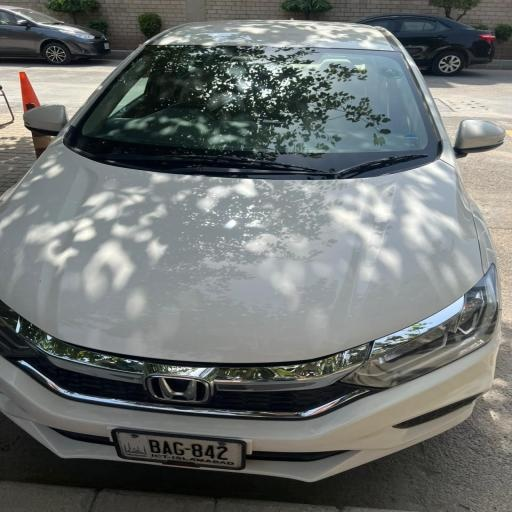

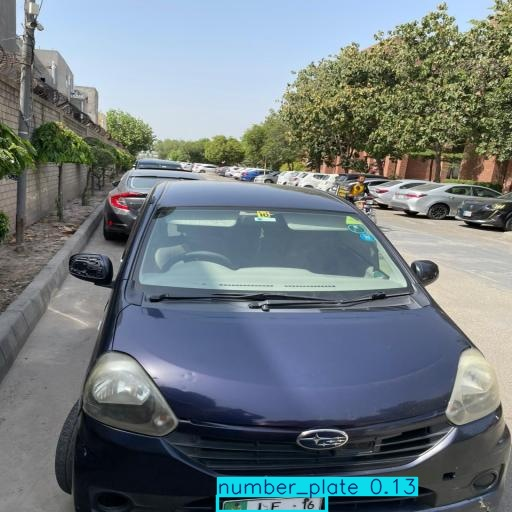

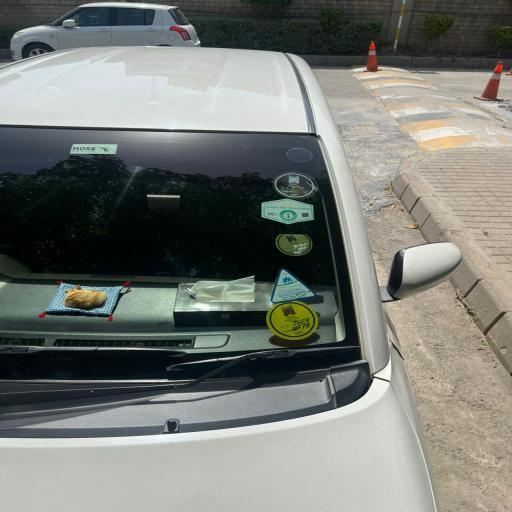

In [13]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob

model = YOLO('/content/best.pt')

# Confidence 0.25 se kam karo
model.predict(
    source='/content/dataset/test/images',
    conf=0.1,
    save=True,
    name='bnu_test2'
)

pred_images = glob.glob('runs/detect/bnu_test2/*.jpg')[:3]
for img in pred_images:
    display(Image(filename=img, width=600))

✅ Database initialized!
⏳ Loading EasyOCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✅ Model + OCR Ready!

📸 Processing: /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-47-39-PM_jpeg.rf.18167b2388833a3607da58efb954fcad.jpg

0: 640x640 (no detections), 7.2ms
Speed: 2.9ms preprocess, 7.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
🚗 Plate: NOT DETECTED
🏷️  BNU Sticker: ❌ NO
📊 Confidence: 0.00
🕐 Time: 2026-05-25 16:34:08


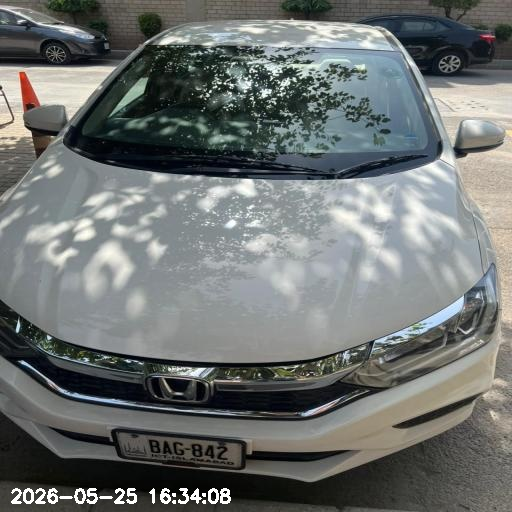


📸 Processing: /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-6-18-29-PM-2-_jpeg.rf.b5d992d34a4ba4ef8d867f8e5a50587f.jpg

0: 640x640 1 number_plate, 11.0ms
Speed: 5.0ms preprocess, 11.0ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
🚗 Plate: NOT DETECTED
🏷️  BNU Sticker: ❌ NO
📊 Confidence: 0.13
🕐 Time: 2026-05-25 16:34:09


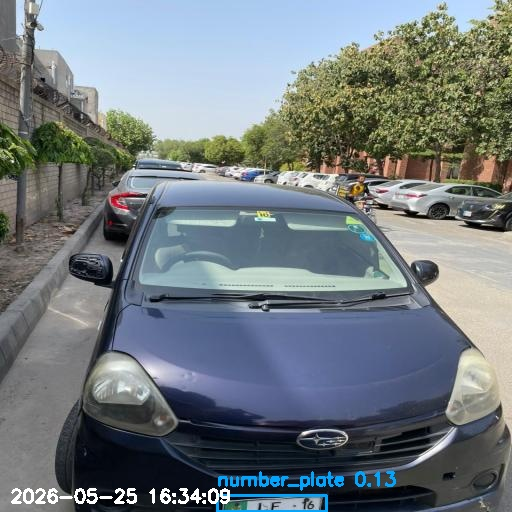


📸 Processing: /content/dataset/test/images/WhatsApp-Image-2026-05-22-at-5-47-59-PM-1-_jpeg.rf.72b3d7823c4e8d2e5d18a702b27c62dd.jpg

0: 640x640 (no detections), 8.2ms
Speed: 6.4ms preprocess, 8.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
🚗 Plate: NOT DETECTED
🏷️  BNU Sticker: ❌ NO
📊 Confidence: 0.00
🕐 Time: 2026-05-25 16:34:09


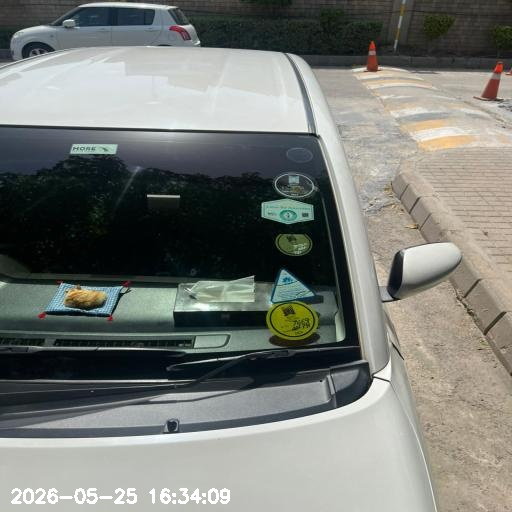

In [14]:
import sqlite3
import easyocr
import cv2
import numpy as np
from ultralytics import YOLO
from datetime import datetime
from IPython.display import display, Image as IPImage
import glob

# ============ DATABASE SETUP ============
DB_PATH = '/content/bnu_vehicles.db'

def init_database():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS vehicle_logs (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            plate_number TEXT,
            bnu_sticker_detected INTEGER,
            confidence REAL,
            timestamp TEXT,
            date TEXT,
            time TEXT
        )
    ''')
    conn.commit()
    conn.close()
    print('✅ Database initialized!')

def log_vehicle(plate_number, bnu_sticker, confidence):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    now = datetime.now()
    cursor.execute('''
        INSERT INTO vehicle_logs
        (plate_number, bnu_sticker_detected, confidence, timestamp, date, time)
        VALUES (?, ?, ?, ?, ?, ?)
    ''', (
        plate_number,
        1 if bnu_sticker else 0,
        confidence,
        now.strftime('%Y-%m-%d %H:%M:%S'),
        now.strftime('%Y-%m-%d'),
        now.strftime('%H:%M:%S')
    ))
    conn.commit()
    conn.close()

init_database()

# ============ OCR + DETECTION ============
print('⏳ Loading EasyOCR...')
reader = easyocr.Reader(['en'], gpu=True)
model = YOLO('/content/best.pt')
print('✅ Model + OCR Ready!')

def detect_and_log(image_path):
    image = cv2.imread(image_path)
    results = model(image, conf=0.1)[0]

    plate_text = 'NOT DETECTED'
    bnu_sticker = False
    max_conf = 0.0

    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = model.names[cls_id]
        bbox = box.xyxy[0].tolist()
        x1, y1, x2, y2 = map(int, bbox)

        if conf > max_conf:
            max_conf = conf

        if label == 'number_plate':
            cropped = image[y1:y2, x1:x2]
            gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
            ocr_result = reader.readtext(gray)
            if ocr_result:
                plate_text = ' '.join([r[1] for r in ocr_result]).upper()

        elif label == 'bnu_sticker':
            bnu_sticker = True

        color = (0, 255, 0) if label == 'bnu_sticker' else (255, 165, 0)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, f'{label} {conf:.2f}', (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Timestamp overlay
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    cv2.putText(image, timestamp, (10, image.shape[0]-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

    if plate_text != 'NOT DETECTED':
        cv2.putText(image, f'PLATE: {plate_text}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

    # Save output
    out_path = f'/content/result_{datetime.now().strftime("%H%M%S")}.jpg'
    cv2.imwrite(out_path, image)

    # Log to DB
    log_vehicle(plate_text, bnu_sticker, max_conf)

    print(f'🚗 Plate: {plate_text}')
    print(f'🏷️  BNU Sticker: {"✅ YES" if bnu_sticker else "❌ NO"}')
    print(f'📊 Confidence: {max_conf:.2f}')
    print(f'🕐 Time: {timestamp}')
    display(IPImage(filename=out_path, width=600))

# Test on all test images
test_images = glob.glob('/content/dataset/test/images/*.jpg')
for img in test_images[:3]:
    print(f'\n📸 Processing: {img}')
    detect_and_log(img)

In [15]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('/content/bnu_vehicles.db')
df = pd.read_sql_query('SELECT * FROM vehicle_logs', conn)
conn.close()

df['bnu_sticker_detected'] = df['bnu_sticker_detected'].map({1: '✅ Yes', 0: '❌ No'})
print(f'📋 Total Records: {len(df)}')
df

📋 Total Records: 3


,id,plate_number,bnu_sticker_detected,confidence,timestamp,date,time
0,1,NOT DETECTED,❌ No,0.000000,2026-05-25 16:34:08,2026-05-25,16:34:08
1,2,NOT DETECTED,❌ No,0.126729,2026-05-25 16:34:09,2026-05-25,16:34:09
2,3,NOT DETECTED,❌ No,0.000000,2026-05-25 16:34:09,2026-05-25,16:34:09


## ✅ Step 5 — Validate Model

In [ ]:
# Validate on validation set
metrics = model.val()

print('\n📊 Validation Results:')
print(f'mAP50:     {metrics.box.map50:.4f}')
print(f'mAP50-95:  {metrics.box.map:.4f}')
print(f'Precision: {metrics.box.mp:.4f}')
print(f'Recall:    {metrics.box.mr:.4f}')

In [ ]:
# Show training results plots
from IPython.display import Image, display
import glob

results_path = f'runs/detect/bnu_detector/'

print('📈 Training Curves:')
display(Image(filename=f'{results_path}results.png', width=900))

print('\n🎯 Confusion Matrix:')
display(Image(filename=f'{results_path}confusion_matrix.png', width=600))

## ✅ Step 6 — Test on Sample Images

In [ ]:
# Load best trained weights
best_model = YOLO(f'runs/detect/bnu_detector/weights/best.pt')

# Test on validation images
test_results = best_model.predict(
    source=f'{dataset.location}/test/images',
    conf=0.25,
    save=True,
    name='bnu_test_results'
)

print('✅ Predictions done!')

In [ ]:
# Show sample predictions
import glob
from IPython.display import Image, display

pred_images = glob.glob('runs/detect/bnu_test_results/*.jpg')[:4]
for img_path in pred_images:
    print(f'📸 {img_path}')
    display(Image(filename=img_path, width=600))

## ✅ Step 7 — Save Weights to Google Drive

In [ ]:
import shutil

# Save to Google Drive
drive_save_path = '/content/drive/MyDrive/BNU_Project/'
os.makedirs(drive_save_path, exist_ok=True)

# Copy best weights
shutil.copy(
    'runs/detect/bnu_detector/weights/best.pt',
    f'{drive_save_path}best.pt'
)

# Copy results folder
shutil.copytree(
    'runs/detect/bnu_detector/',
    f'{drive_save_path}training_results/',
    dirs_exist_ok=True
)

print('✅ Weights saved to Google Drive!')
print(f'📁 Location: {drive_save_path}')

## ✅ Step 8 — OCR Setup (EasyOCR for Number Plates)

In [ ]:
import easyocr
import cv2
import numpy as np
from PIL import Image as PILImage

# Initialize OCR reader
reader = easyocr.Reader(['en'], gpu=True)
print('✅ EasyOCR initialized!')

def extract_plate_text(image, bbox):
    """
    Crop number plate region and extract text using OCR
    bbox format: [x1, y1, x2, y2]
    """
    x1, y1, x2, y2 = map(int, bbox)
    cropped = image[y1:y2, x1:x2]

    # Preprocess for better OCR
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # OCR
    results = reader.readtext(thresh)
    plate_text = ' '.join([r[1] for r in results])
    return plate_text.strip().upper()

print('✅ OCR function ready!')

## ✅ Step 9 — SQLite Database Setup

In [ ]:
import sqlite3
from datetime import datetime

# Create database
DB_PATH = '/content/drive/MyDrive/BNU_Project/bnu_vehicles.db'

def init_database():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute('''
        CREATE TABLE IF NOT EXISTS vehicle_logs (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            plate_number TEXT,
            bnu_sticker_detected INTEGER,
            confidence REAL,
            timestamp TEXT,
            date TEXT,
            time TEXT,
            image_path TEXT
        )
    ''')

    conn.commit()
    conn.close()
    print('✅ Database initialized!')
    return DB_PATH

def log_vehicle(plate_number, bnu_sticker_detected, confidence, image_path=''):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    now = datetime.now()
    cursor.execute('''
        INSERT INTO vehicle_logs
        (plate_number, bnu_sticker_detected, confidence, timestamp, date, time, image_path)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', (
        plate_number,
        1 if bnu_sticker_detected else 0,
        confidence,
        now.strftime('%Y-%m-%d %H:%M:%S'),
        now.strftime('%Y-%m-%d'),
        now.strftime('%H:%M:%S'),
        image_path
    ))

    conn.commit()
    conn.close()

def view_logs(limit=10):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute('SELECT * FROM vehicle_logs ORDER BY id DESC LIMIT ?', (limit,))
    rows = cursor.fetchall()
    conn.close()
    return rows

# Initialize
init_database()

## ✅ Step 10 — Complete Detection Pipeline (Image Input)

In [ ]:
import cv2
import numpy as np
from datetime import datetime
from IPython.display import Image as IPImage, display

def detect_and_log(image_path):
    """
    Full pipeline: detect sticker + plate → OCR → log to DB
    """
    image = cv2.imread(image_path)
    if image is None:
        print('❌ Image not found!')
        return

    # Run detection
    results = best_model(image, conf=0.25)[0]

    plate_text = 'NOT DETECTED'
    bnu_sticker = False
    max_conf = 0.0

    # Process detections
    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = best_model.names[cls_id]
        bbox = box.xyxy[0].tolist()

        if conf > max_conf:
            max_conf = conf

        if label == 'number_plate':
            plate_text = extract_plate_text(image, bbox)

        elif label == 'bnu_sticker':
            bnu_sticker = True

        # Draw bounding box
        x1, y1, x2, y2 = map(int, bbox)
        color = (0, 255, 0) if label == 'bnu_sticker' else (255, 165, 0)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, f'{label} {conf:.2f}', (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Add plate text overlay
    if plate_text != 'NOT DETECTED':
        cv2.putText(image, f'PLATE: {plate_text}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    # Add timestamp
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    cv2.putText(image, timestamp, (10, image.shape[0]-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    # Save result image
    output_path = f'/content/result_{datetime.now().strftime("%H%M%S")}.jpg'
    cv2.imwrite(output_path, image)

    # Log to database
    log_vehicle(plate_text, bnu_sticker, max_conf, output_path)

    # Display
    print(f'🚗 Plate: {plate_text}')
    print(f'🏷️  BNU Sticker: {"✅ YES" if bnu_sticker else "❌ NO"}')
    print(f'📊 Confidence: {max_conf:.2f}')
    print(f'🕐 Time: {timestamp}')
    print(f'💾 Logged to database!')
    display(IPImage(filename=output_path, width=700))

# Test with a sample image
# detect_and_log('/path/to/your/test/image.jpg')
print('✅ Detection pipeline ready! Call detect_and_log(image_path) to test.')

## ✅ Step 11 — View Database Logs

In [ ]:
import pandas as pd

def show_logs_table():
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query('SELECT * FROM vehicle_logs ORDER BY id DESC', conn)
    conn.close()

    df['bnu_sticker_detected'] = df['bnu_sticker_detected'].map({1: '✅ Yes', 0: '❌ No'})

    print(f'📋 Total Records: {len(df)}')
    return df

show_logs_table()

## ✅ Step 12 — Export Results Summary

In [ ]:
# Export logs to CSV
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query('SELECT * FROM vehicle_logs', conn)
conn.close()

csv_path = '/content/drive/MyDrive/BNU_Project/vehicle_logs.csv'
df.to_csv(csv_path, index=False)
print(f'✅ Logs exported to: {csv_path}')
print(f'📊 Total vehicles logged: {len(df)}')
print(f'🏷️  BNU Stickers detected: {df["bnu_sticker_detected"].sum()}')

---
## 🎉 Project Complete!

### 📦 Deliverables Saved in Google Drive `/BNU_Project/`:
| File | Description |
|---|---|
| `best.pt` | Trained model weights |
| `training_results/` | All training graphs & metrics |
| `bnu_vehicles.db` | SQLite database with logs |
| `vehicle_logs.csv` | Exported data CSV |

### 📊 Model Performance:
- Run **Step 5** to see mAP, Precision, Recall
- Run **Step 6** to see confusion matrix

### 🚀 Next Step:
Run the **Real-time Camera App** (separate script provided)